In [ ]:
!pip install -q kaggle pandas numpy scikit-learn xgboost matplotlib seaborn joblib flask-ngrok


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 344MB/s]
Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, classification_report,
                           confusion_matrix)
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nMissing values after conversion: {df['TotalCharges'].isnull().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


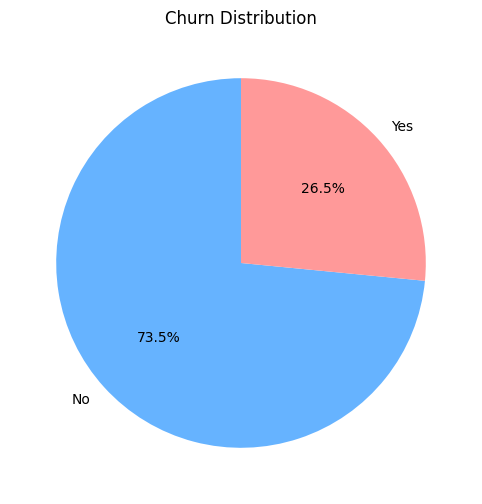

In [ ]:
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Churn Distribution')
plt.show()


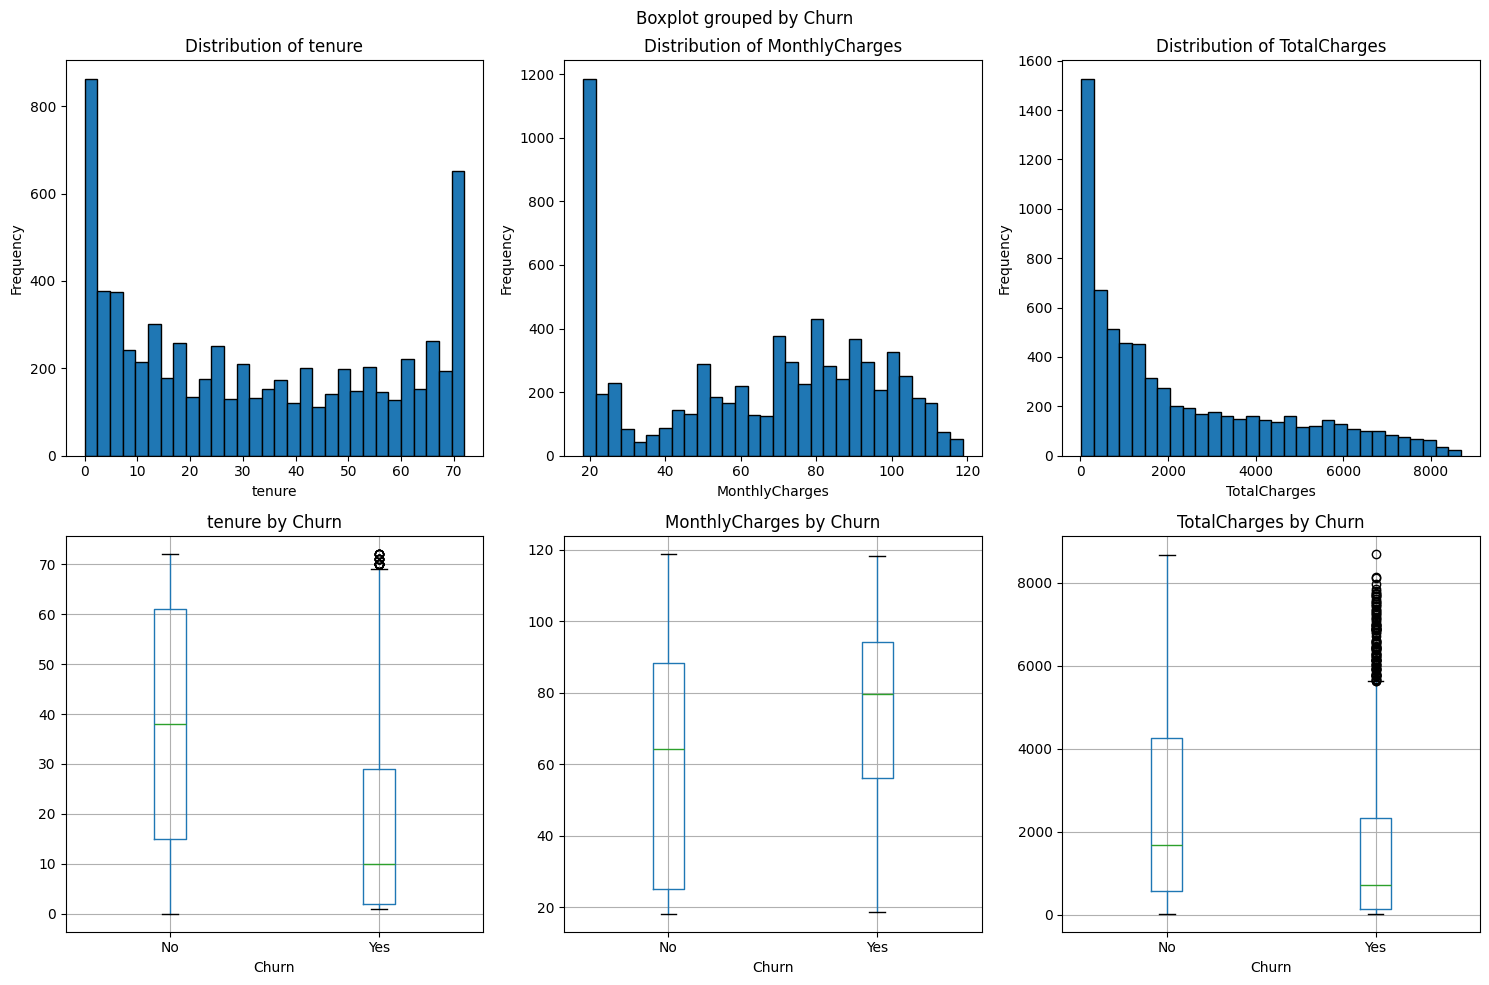

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    axes[0, i].hist(df[feature].dropna(), bins=30, edgecolor='black')
    axes[0, i].set_title(f'Distribution of {feature}')
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel('Frequency')

    df.boxplot(column=feature, by='Churn', ax=axes[1, i])
    axes[1, i].set_title(f'{feature} by Churn')
    axes[1, i].set_xlabel('Churn')

plt.tight_layout()
plt.show()

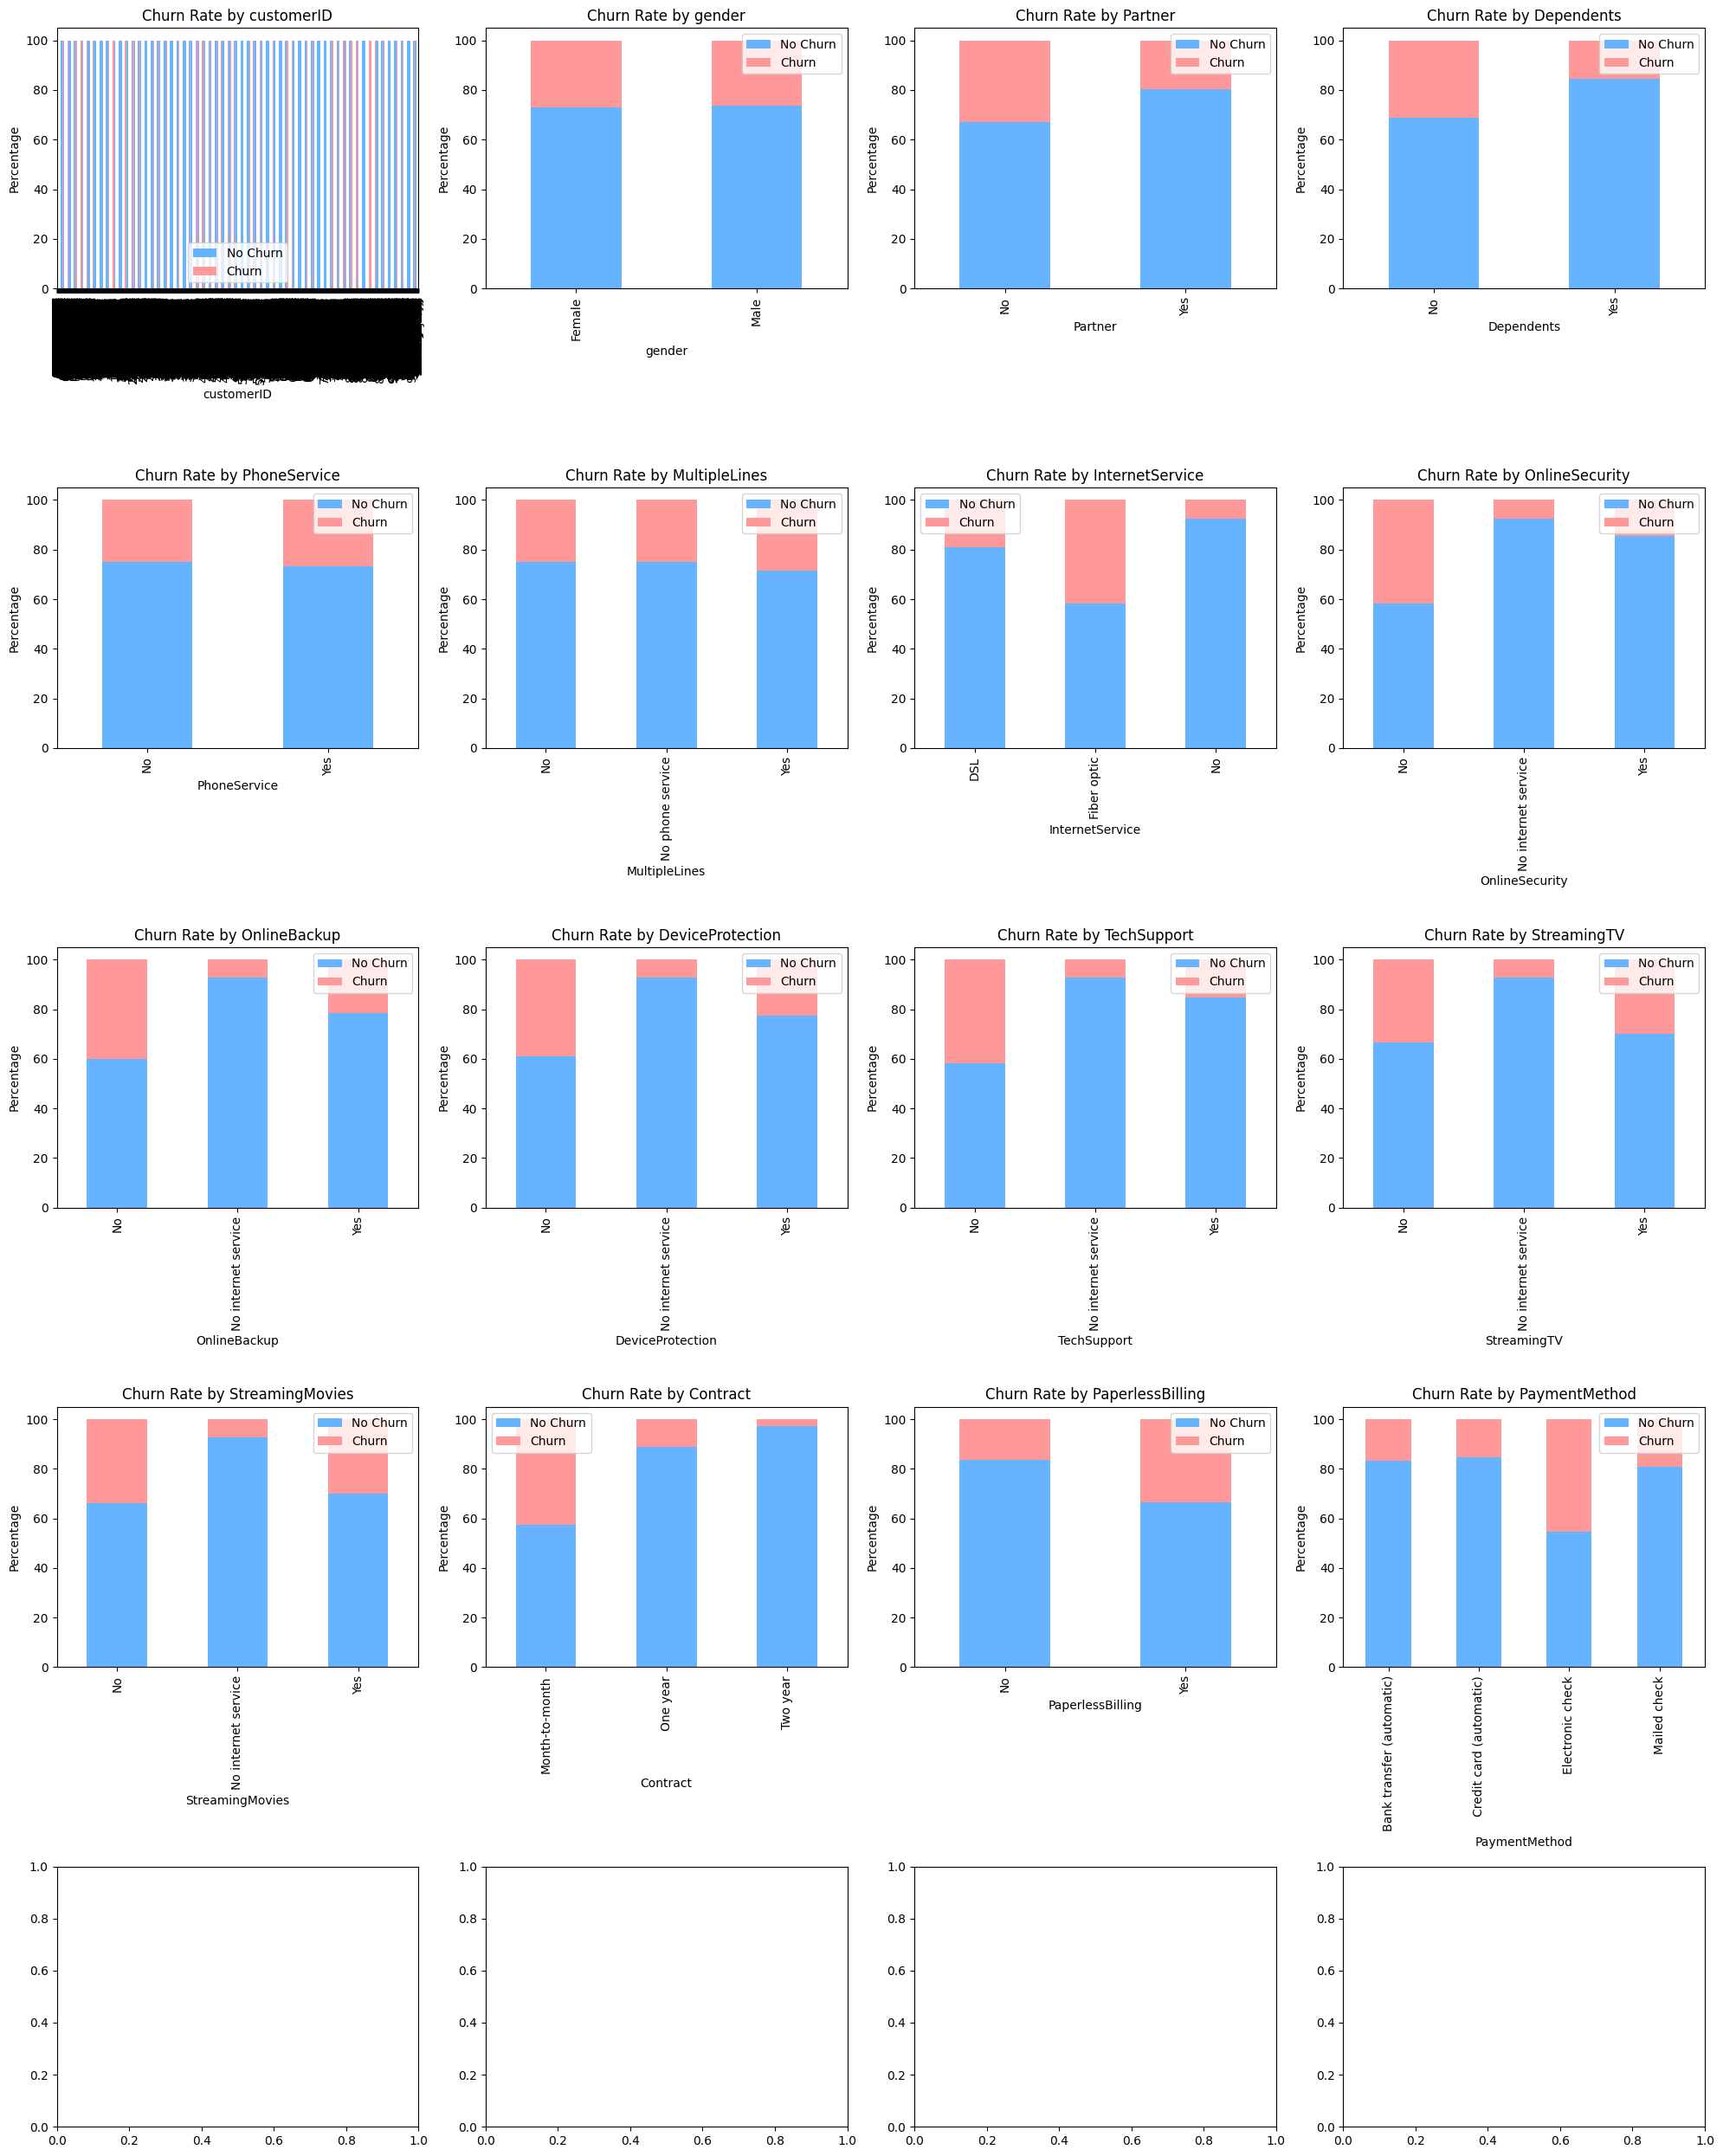

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Churn')
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols[:20]):
    churn_by_category = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    churn_by_category.plot(kind='bar', stacked=True, ax=axes[idx],
                          color=['#66b3ff', '#ff9999'])
    axes[idx].set_title(f'Churn Rate by {col}')
    axes[idx].set_ylabel('Percentage')
    axes[idx].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

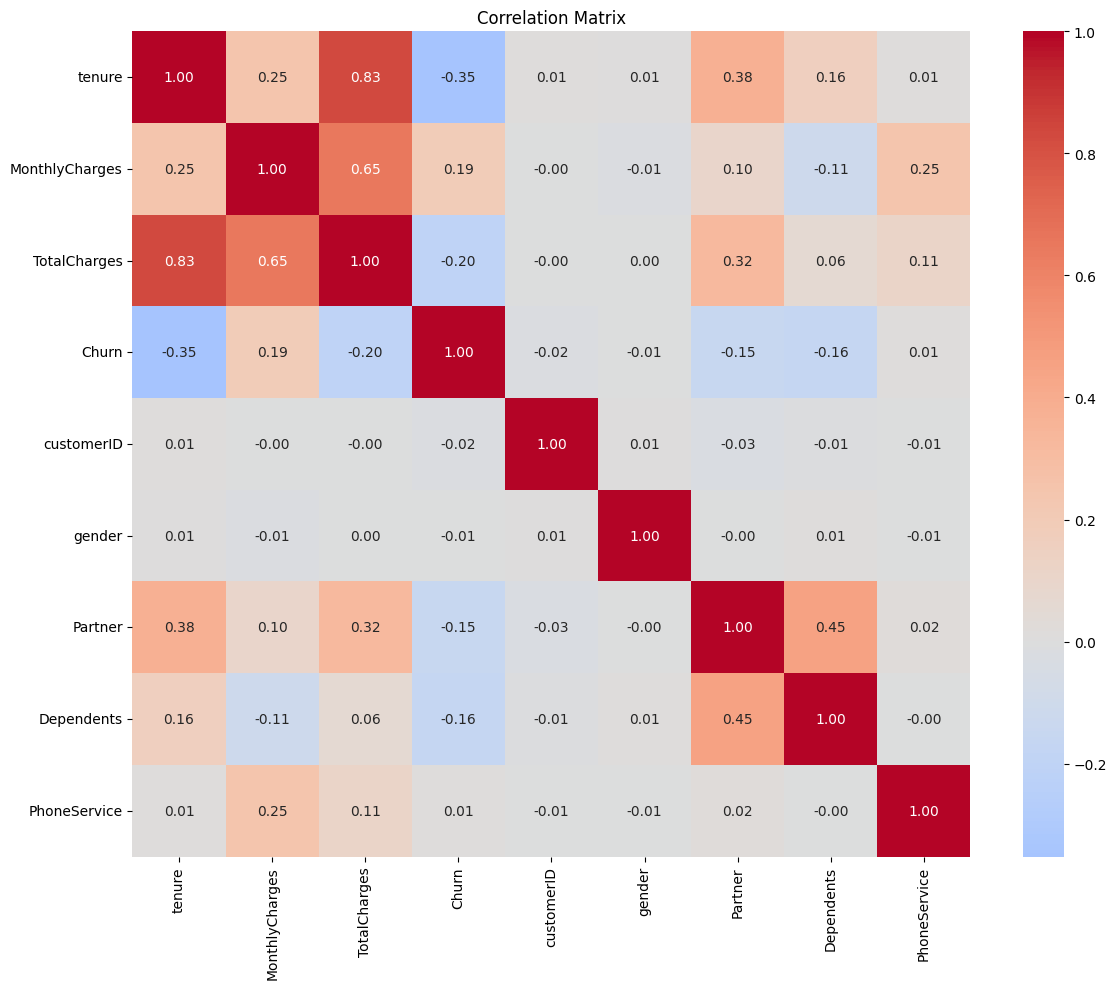

In [ ]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
for col in categorical_cols:
    df_corr[col] = le.fit_transform(df_corr[col])

plt.figure(figsize=(12, 10))
correlation_matrix = df_corr[numerical_features + ['Churn'] + list(categorical_cols[:5])].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.drop('customerID', axis=1, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Churn')

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Churn rate in training: {y_train.mean():.3f}")
print(f"Churn rate in test: {y_test.mean():.3f}")

Training set size: (5634, 19)
Test set size: (1409, 19)
Churn rate in training: 0.265
Churn rate in test: 0.265


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }




Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...

Training XGBoost...



Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7999     0.6447  0.5481    0.5925   0.8403
Random Forest          0.7935     0.6388  0.5107    0.5676   0.8219
Gradient Boosting      0.8013     0.6655  0.5053    0.5745   0.8449
XGBoost                0.7786     0.5957  0.5160    0.5530   0.8185


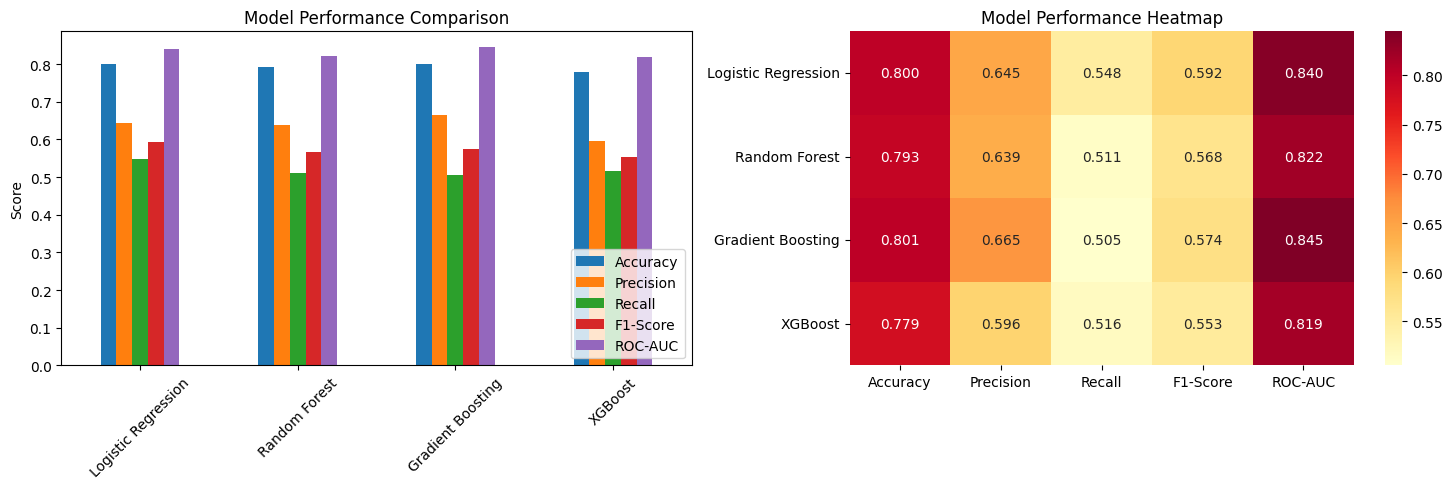

In [ ]:
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

sns.heatmap(results_df, annot=True, cmap='YlOrRd', ax=axes[1], fmt='.3f')
axes[1].set_title('Model Performance Heatmap')

plt.tight_layout()
plt.show()

Best Model: Logistic Regression

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



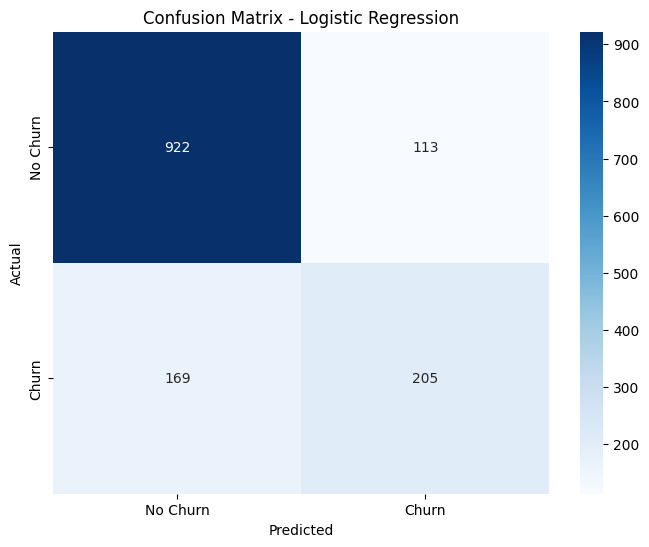

In [ ]:
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.show()

    print("\nTop 10 Important Features:")
    print(feature_importance.head(10))

In [ ]:
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    model_to_tune = RandomForestClassifier(random_state=42)
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0]
    }
    model_to_tune = XGBClassifier(random_state=42, eval_metric='logloss')
else:
    print("Skipping hyperparameter tuning for non-tree based model")
    model_to_tune = None

if model_to_tune:
    grid_search = GridSearchCV(
        model_to_tune, param_grid, cv=5,
        scoring='f1', n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)

    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best F1-Score: {grid_search.best_score_:.4f}")

    best_tuned_model = grid_search.best_estimator_
    y_pred_tuned = best_tuned_model.predict(X_test)
    print(f"\nTuned Model Test F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")

Skipping hyperparameter tuning for non-tree based model


In [ ]:
joblib.dump(best_model, 'churn_model.pkl')

# Save preprocessors
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Model and preprocessors saved successfully!")


Model and preprocessors saved successfully!


In [ ]:
from google.colab import files

files.download('churn_model.pkl')
files.download('label_encoders.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>